# ML4T Library: Volume Participation Limits

**Docker image**: `ml4t`

This notebook demonstrates **VolumeParticipationLimit** from ml4t.backtest.execution
for realistic institutional order execution:

1. **Volume Participation Concept**: Why institutions limit market footprint
2. **VolumeParticipationLimit API**: Parameters and behavior
3. **Partial Fills Over Multiple Bars**: Large orders split automatically
4. **Participation Rate Comparison**: 5%, 10%, 25% limits
5. **Real-World Scenario**: Large order with volume constraints
6. **Integration with Impact Models**: Full execution realism

**Key Insight**: Large institutional orders cannot be filled instantly without
moving markets. Volume participation limits enforce realistic execution by
spreading fills across multiple bars based on available liquidity.

**Learning Objectives**
- Explain why desks cap participation as a fraction of available bar volume
- Interpret `ExecutionResult` fields from the ML4T execution broker
- Simulate partial fills across bars and days under different participation caps
- Combine quantity limits with impact-adjusted fill pricing

**Book Reference:** Chapter 18, Section 18.5 (Execution Algorithms as Controls)

**Prerequisites:** Read [`06_ml4t_execution_demo`](06_ml4t_execution_demo.ipynb) for impact-model APIs and
[`04_vwap_twap_execution`](04_vwap_twap_execution.ipynb) for benchmark scheduling logic.

## Imports & Setup

In [1]:
"""ML4T Volume Participation - Realistic execution constraints on real NASDAQ-100 liquidity."""

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import polars as pl
from ml4t.backtest.execution import (
    SquareRootImpact,
    VolumeParticipationLimit,
)
from plotly.subplots import make_subplots

import utils  # noqa: F401  — sys.path side-effect; enables `from data import ...`
from data import load_nasdaq100_bars
from utils.reproducibility import set_global_seeds

In [2]:
# A parent order is released against a real intraday sequence of (volume, price)
# intervals built from AlgoSeek NASDAQ-100 minute bars. The participation cap is
# applied to each interval's *actual* traded volume, so completion time and
# realized price come entirely from real liquidity — no synthetic volume curves.
EXEC_SYMBOLS = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]  # liquid NASDAQ-100 names
PRIMARY_SYMBOL = "AAPL"  # symbol whose real sessions drive the execution walk
TAQ_START_DATE = "2021-10-01"
TAQ_END_DATE = "2021-12-31"
INTERVAL_MINUTES = 15  # execution grid; 09:30-16:00 → 26 intervals/session
ORDER_PCT_ADV = 0.5  # parent order as a fraction of measured ADV
PARTICIPATION_RATES = [0.05, 0.10, 0.25]
SEED = 42

In [3]:
set_global_seeds(SEED)

## Part 1: Why Volume Participation Limits?

Institutional traders face a fundamental constraint: **you cannot execute more
than a fraction of market volume without moving prices against you**.

### The Problem

| Order Size | % of Daily Volume | Expected Impact |
|------------|-------------------|-----------------|
| 10,000 shares | 1% | Minimal |
| 100,000 shares | 10% | Moderate |
| 500,000 shares | 50% | Severe |

### Industry Practice

Institutional desks typically limit participation to **5-20% of volume**:
- **5%**: Very conservative (stealth execution)
- **10%**: Standard (balanced impact/speed)
- **20%**: Aggressive (urgent execution)
- **25%+**: Only for very liquid names or urgent situations

In [4]:
# Demonstrate the VolumeParticipationLimit API
limit = VolumeParticipationLimit(max_participation=0.10)

print("VolumeParticipationLimit Configuration")
print("=" * 50)
print(f"Max Participation Rate: {limit.max_participation:.0%}")
print(f"Min Volume Threshold:   {limit.min_volume:,.0f}")

# Example calculation
order_qty = 50_000  # shares
bar_volume = 100_000  # shares
price = 150.0

result = limit.calculate(order_qty, bar_volume, price)

print(f"\nExample: {order_qty:,} share order, {bar_volume:,} bar volume")
print(f"  Max fillable (10%):  {bar_volume * 0.10:,.0f} shares")
print(f"  Fillable quantity:   {result.fillable_quantity:,.0f} shares")
print(f"  Remaining quantity:  {result.remaining_quantity:,.0f} shares")
print(f"  Participation rate:  {result.participation_rate:.1%}")
print(f"  Is partial fill:     {result.is_partial}")

VolumeParticipationLimit Configuration
Max Participation Rate: 10%
Min Volume Threshold:   0

Example: 50,000 share order, 100,000 bar volume
  Max fillable (10%):  10,000 shares
  Fillable quantity:   10,000 shares
  Remaining quantity:  40,000 shares
  Participation rate:  10.0%
  Is partial fill:     True


**Finding**: The first example shows why participation limits matter even for
moderate orders. A 50,000-share parent order in a 100,000-share bar still only
releases a 10,000-share child order when the desk caps footprint at 10%.

## Part 2: The ExecutionResult Object

When VolumeParticipationLimit calculates fillable quantity, it returns an
`ExecutionResult` with complete execution details:

```python
@dataclass
class ExecutionResult:
    fillable_quantity: float    # Shares that can fill this bar
    remaining_quantity: float   # Shares queued for next bar
    adjusted_price: float       # Price (may include impact)
    impact_cost: float          # Market impact cost
    participation_rate: float   # Actual % of volume used
```

In [5]:
# Demonstrate different execution scenarios under a 10% participation limit.
limit = VolumeParticipationLimit(max_participation=0.10)
price = 100.0

scenarios = [
    ("Small order (within limit)", 5_000, 100_000),
    ("Medium order (at limit)", 10_000, 100_000),
    ("Large order (exceeds limit)", 50_000, 100_000),
    ("Very large order (5x limit)", 100_000, 100_000),
    ("Low volume bar", 10_000, 10_000),
    ("No volume data", 10_000, None),
]

scenario_rows = []
for name, order_qty, volume in scenarios:
    result = limit.calculate(order_qty, volume, price)
    scenario_rows.append(
        {
            "scenario": name,
            "order_qty": order_qty,
            "bar_volume": volume,
            "fill_qty": result.fillable_quantity,
            "remaining_qty": result.remaining_quantity,
            "participation_rate": result.participation_rate if volume else None,
        }
    )

scenarios_df = pl.DataFrame(scenario_rows)
scenarios_df

scenario,order_qty,bar_volume,fill_qty,remaining_qty,participation_rate
str,i64,i64,f64,f64,f64
"""Small order (within limit)""",5000,100000,5000.0,0.0,0.05
"""Medium order (at limit)""",10000,100000,10000.0,0.0,0.1
"""Large order (exceeds limit)""",50000,100000,10000.0,40000.0,0.1
"""Very large order (5x limit)""",100000,100000,10000.0,90000.0,0.1
"""Low volume bar""",10000,10000,1000.0,9000.0,0.1
"""No volume data""",10000,null,10000.0,0.0,null


**Finding**: `ExecutionResult` turns a limit rule into operational state. The
remaining quantity is the broker's queue for the next bar whenever current
liquidity cannot absorb the order safely.

## Part 3: Real Intraday Liquidity

The participation cap is only meaningful against *real* liquidity. We load
AlgoSeek NASDAQ-100 minute bars, aggregate them onto a 15-minute execution
grid, and build a single consecutive sequence of intervals (each carrying its
actual traded volume and volume-weighted price) for one liquid name. The
parent order walks that real sequence interval by interval.

In [6]:
def load_intraday_panel(
    symbols: list[str],
    start_date: str,
    end_date: str,
    interval_minutes: int,
) -> pl.DataFrame:
    """Aggregate real minute bars onto an intraday execution grid.

    Returns per (symbol, date, bucket) the interval volume and the
    volume-weighted trade price, restricted to the regular session (09:30-16:00).
    """
    session_start = 9 * 60 + 30  # 09:30 as minute-of-day
    session_end = 16 * 60  # 16:00
    return (
        load_nasdaq100_bars(
            start_date=start_date,
            end_date=end_date,
            include_microstructure=True,
            lazy=True,
        )
        .filter(pl.col("symbol").is_in(symbols))
        .select("timestamp", "symbol", "volume", "last_trade_price")
        .filter(pl.col("last_trade_price").is_not_null() & (pl.col("volume") > 0))
        .with_columns(
            date=pl.col("timestamp").dt.date(),
            minute_of_day=pl.col("timestamp").dt.hour().cast(pl.Int32) * 60
            + pl.col("timestamp").dt.minute().cast(pl.Int32),
        )
        .filter(
            (pl.col("minute_of_day") >= session_start) & (pl.col("minute_of_day") < session_end)
        )
        .with_columns(
            bucket=((pl.col("minute_of_day") - session_start) // interval_minutes).cast(pl.Int32)
        )
        .group_by("symbol", "date", "bucket")
        .agg(
            volume=pl.col("volume").sum(),
            price=(pl.col("last_trade_price") * pl.col("volume")).sum() / pl.col("volume").sum(),
        )
        .sort("symbol", "date", "bucket")
        .collect()
    )

In [7]:
panel = load_intraday_panel(EXEC_SYMBOLS, TAQ_START_DATE, TAQ_END_DATE, INTERVAL_MINUTES)

# Consecutive real intervals for the primary symbol, in chronological order.
seq = panel.filter(pl.col("symbol") == PRIMARY_SYMBOL).sort("date", "bucket")
interval_volume = seq["volume"].to_numpy()
interval_price = seq["price"].to_numpy()
interval_date = seq["date"].to_list()

adv = float(seq.group_by("date").agg(dv=pl.col("volume").sum())["dv"].mean())
order_shares = int(round(ORDER_PCT_ADV * adv))

print(f"Primary symbol: {PRIMARY_SYMBOL}")
print(f"Real intervals: {len(interval_volume):,} across {seq['date'].n_unique()} sessions")
print(f"Measured ADV:   {adv:,.0f} shares")
print(f"Parent order:   {order_shares:,} shares ({ORDER_PCT_ADV:.0%} of ADV)")

Primary symbol: AAPL
Real intervals: 1,664 across 64 sessions
Measured ADV:   38,722,531 shares
Parent order:   19,361,266 shares (50% of ADV)


**Finding**: The parent order is a fixed fraction of the symbol's measured ADV,
so it is genuinely large relative to a single session's liquidity. That is the
regime where a participation cap actually binds — small orders clear in one
interval and never exercise the constraint.

### Walk the Parent Order Against Real Intervals

At each real interval, the broker releases at most `cap × interval_volume`
shares and queues the remainder for the next interval. Volume and price both
come from the data; only the cap changes between runs.

In [8]:
def participation_walk(
    volumes: np.ndarray,
    prices: np.ndarray,
    dates: list,
    order_shares: int,
    max_participation: float,
    min_volume: float = 0.0,
) -> pl.DataFrame:
    """Release a parent order against a real (volume, price) interval sequence."""
    limit = VolumeParticipationLimit(max_participation=max_participation, min_volume=min_volume)
    remaining = order_shares
    rows = []
    day_index = {d: i for i, d in enumerate(sorted(set(dates)))}
    for i, (vol, px, d) in enumerate(zip(volumes, prices, dates)):
        if remaining <= 0:
            break
        result = limit.calculate(remaining, float(vol), float(px))
        if result.fillable_quantity <= 0:
            continue
        rows.append(
            {
                "bar": len(rows),
                "interval": i,
                "day": day_index[d],
                "date": d,
                "bar_volume": float(vol),
                "price": float(px),
                "fill_qty": result.fillable_quantity,
                "remaining": result.remaining_quantity,
                "participation": result.participation_rate,
            }
        )
        remaining = result.remaining_quantity
    if remaining > 0:
        print(
            f"WARNING: parent order not fully filled — {remaining:,} of "
            f"{order_shares:,} shares remain after {len(rows)} intervals "
            f"(data window exhausted before completion)"
        )
    df = pl.DataFrame(rows)
    if df.height == 0:
        return df
    return df.with_columns(
        cumulative_shares=pl.col("fill_qty").cum_sum(),
        cumulative_cost=(pl.col("fill_qty") * pl.col("price")).cum_sum(),
    ).with_columns(pct_complete=pl.col("cumulative_shares") / order_shares * 100)

In [9]:
# Run the walk for each participation cap against the same real interval sequence.
results = {
    rate: participation_walk(interval_volume, interval_price, interval_date, order_shares, rate)
    for rate in PARTICIPATION_RATES
}

print("Participation Rate Comparison")
print(f"Order: {order_shares:,} shares ({PRIMARY_SYMBOL}, {ORDER_PCT_ADV:.0%} of ADV)")
print("=" * 70)
for rate, df in results.items():
    print(
        f"{rate:>5.0%} limit: {df.height:>3} intervals to complete, "
        f"{df['day'].max() + 1:>2} sessions, "
        f"avg participation: {df['participation'].mean():.1%}"
    )

Participation Rate Comparison
Order: 19,361,266 shares (AAPL, 50% of ADV)
   5% limit: 307 intervals to complete, 12 sessions, avg participation: 5.0%
  10% limit: 135 intervals to complete,  6 sessions, avg participation: 10.0%
  25% limit:  50 intervals to complete,  2 sessions, avg participation: 24.6%


**Finding**: Against real liquidity the cap is the only lever that changes, so
differences in intervals-to-complete and sessions-to-complete are attributable
directly to footprint discipline. A tighter cap stretches the same parent order
across more real intervals and more trading sessions.

### Plot Completion Paths by Participation Limit

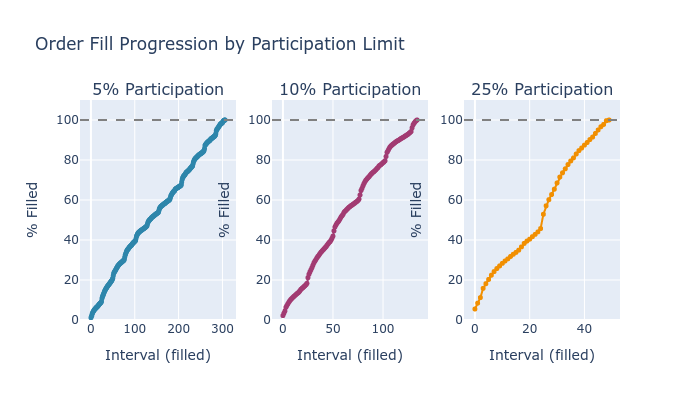

In [10]:
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=["5% Participation", "10% Participation", "25% Participation"],
)

colors = ["#2E86AB", "#A23B72", "#F18F01"]

for i, (rate, df) in enumerate(results.items()):
    if df.height == 0:
        continue
    fig.add_scatter(
        x=df["bar"].to_list(),
        y=df["pct_complete"].to_list(),
        mode="lines+markers",
        name=f"{rate:.0%}",
        line=dict(color=colors[i], width=2),
        marker=dict(size=5),
        row=1,
        col=i + 1,
    )
    fig.add_hline(y=100, line_dash="dash", line_color="gray", row=1, col=i + 1)

fig.update_xaxes(title_text="Interval (filled)")
fig.update_yaxes(title_text="% Filled", range=[0, 110])
fig.update_layout(
    title="Order Fill Progression by Participation Limit",
    height=400,
    showlegend=False,
)
fig.show()

**Finding**: Completion time scales roughly inversely with the cap. Against real
AAPL liquidity the half-ADV order clears in 307 intervals (12 sessions) at a 5%
cap, 135 intervals (6 sessions) at 10%, and 50 intervals (2 sessions) at 25%.
Each step up in the cap shortens the horizon about proportionally; the price paid
is a proportionally larger participation share each interval, and therefore more
market-impact risk per fill.

## Part 4: Large Order Execution Timeline

The same real walk yields the operational outcomes a portfolio manager trades
off: intervals and sessions to completion, realized VWAP against real prices,
and the actual participation share consumed each interval.

In [11]:
# Summarize each cap's real execution outcome.
for rate, df in results.items():
    if df.height == 0:
        continue
    vwap = df["cumulative_cost"][-1] / df["cumulative_shares"][-1]
    print(f"\n{rate:.0%} Participation Limit:")
    print(f"  Intervals to complete:  {df.height}")
    print(f"  Sessions to complete:   {df['day'].max() + 1}")
    print(f"  Realized VWAP:          ${vwap:.4f}")
    print(f"  Avg participation:      {df['participation'].mean():.1%}")


5% Participation Limit:
  Intervals to complete:  307
  Sessions to complete:   12
  Realized VWAP:          $141.9041
  Avg participation:      5.0%

10% Participation Limit:
  Intervals to complete:  135
  Sessions to complete:   6
  Realized VWAP:          $140.9324
  Avg participation:      10.0%

25% Participation Limit:
  Intervals to complete:  50
  Sessions to complete:   2
  Realized VWAP:          $140.2128
  Avg participation:      24.6%


**Finding**: Realized VWAP differs across caps ($141.90 at 5%, $140.93 at 10%,
$140.21 at 25%) purely because the three executions span different windows of a
trending market: AAPL rose through Q4 2021, so the tighter cap — finishing 12
sessions later — averaged over higher prices. That is timing/drift risk, the
genuine cost of slow execution, and it is distinct from the per-interval
participation footprint that the participation-rate panel measures.

### Visualize Execution Timeline

In [12]:
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Cumulative Fill (%)",
        "Fill Size per Interval",
        "Execution Price Path",
        "Participation Rate",
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.1,
)

colors = {0.05: "#2E86AB", 0.10: "#A23B72", 0.25: "#F18F01"}

### Trace Helper for the Four-Panel Diagnostic

In [13]:
def add_execution_traces(fig, df: pl.DataFrame, rate: float, color: str) -> None:
    name = f"{rate:.0%}"
    bars = df["bar"].to_list()
    marker = dict(color=color, size=4, opacity=0.6)
    panels = [
        (df["pct_complete"].to_list(), "lines", dict(color=color, width=2), 1, 1, True),
        (df["fill_qty"].to_list(), "markers", marker, 1, 2, False),
        (df["price"].to_list(), "lines", dict(color=color, width=1), 2, 1, False),
        ([p * 100 for p in df["participation"].to_list()], "markers", marker, 2, 2, False),
    ]
    for values, mode, style, row, col, showlegend in panels:
        fig.add_scatter(
            x=bars,
            y=values,
            mode=mode,
            name=name,
            row=row,
            col=col,
            showlegend=showlegend,
            line=style if mode == "lines" else None,
            marker=style if mode == "markers" else None,
        )

In [14]:
for rate, df in results.items():
    if df.height == 0:
        continue
    add_execution_traces(fig, df, rate, colors[rate])

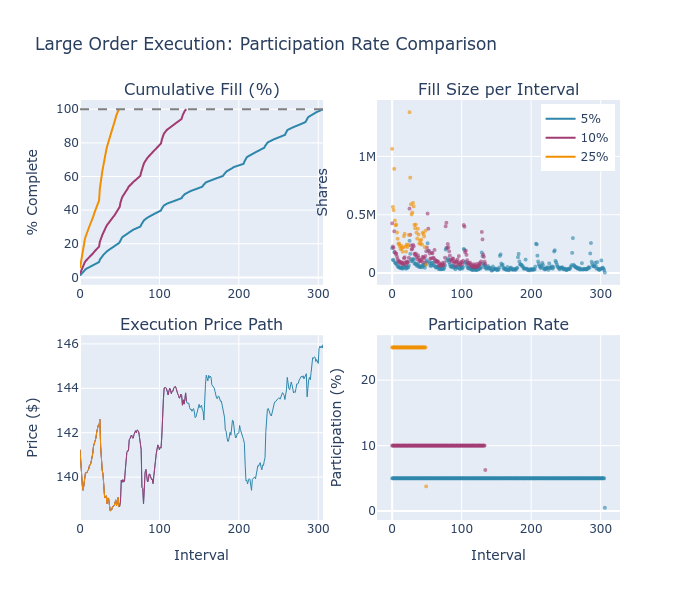

In [15]:
# Finalize execution diagnostics panel
fig.add_hline(y=100, line_dash="dash", line_color="gray", row=1, col=1)

fig.update_xaxes(title_text="Interval", row=2, col=1)
fig.update_xaxes(title_text="Interval", row=2, col=2)
fig.update_yaxes(title_text="% Complete", row=1, col=1)
fig.update_yaxes(title_text="Shares", row=1, col=2)
fig.update_yaxes(title_text="Price ($)", row=2, col=1)
fig.update_yaxes(title_text="Participation (%)", row=2, col=2)

fig.update_layout(
    title="Large Order Execution: Participation Rate Comparison",
    height=600,
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99),
)
fig.show()

**Finding**: The execution timeline makes the trade-off visible. Conservative
limits stretch the order over more real intervals and sessions, while aggressive
limits raise fill size per interval and therefore increase the likelihood of
adverse impact when liquidity is thin.

## Part 5: Combining with Market Impact Models

For complete execution realism, combine:

1. **VolumeParticipationLimit**: Controls *how much* can fill per bar
2. **MarketImpactModel**: Adjusts *price* based on participation

The broker applies both in sequence.

### Combined Volume-Limit and Impact Pricing Example

In [16]:
# Demonstrate combined volume limit + impact
volume_limit = VolumeParticipationLimit(max_participation=0.10)
impact_model = SquareRootImpact(coefficient=0.5, volatility=0.02)

# Scenario
order_qty = 50_000
bar_volume = 100_000
price = 100.0
is_buy = True

# Step 1: Apply volume limit
exec_result = volume_limit.calculate(order_qty, bar_volume, price)
fill_qty = exec_result.fillable_quantity

# Step 2: Apply market impact
impact = impact_model.calculate(fill_qty, price, bar_volume, is_buy)
fill_price = price + impact

In [17]:
print("Combined Execution Model")
print("=" * 60)
print("\n1. Volume Participation Limit (10%):")
print(f"   Order quantity:     {order_qty:,} shares")
print(f"   Bar volume:         {bar_volume:,} shares")
print(f"   Max fillable:       {bar_volume * 0.10:,.0f} shares")
print(f"   Actual fill:        {fill_qty:,.0f} shares")
print(f"   Remaining:          {exec_result.remaining_quantity:,.0f} shares")

print("\n2. Market Impact (Square Root):")
print(f"   Fill quantity:      {fill_qty:,.0f} shares")
print(f"   Base price:         ${price:.4f}")
print(f"   Price impact:       ${impact:.4f} ({impact / price * 10000:.1f} bps)")
print(f"   Fill price:         ${fill_price:.4f}")

print("\n3. Total Execution Cost:")
notional = fill_qty * price
impact_cost = fill_qty * impact
print(f"   Notional:           ${notional:,.2f}")
print(f"   Impact cost:        ${impact_cost:,.2f}")
print(f"   Total cost:         ${notional + impact_cost:,.2f}")

Combined Execution Model

1. Volume Participation Limit (10%):
   Order quantity:     50,000 shares
   Bar volume:         100,000 shares
   Max fillable:       10,000 shares
   Actual fill:        10,000 shares
   Remaining:          40,000 shares

2. Market Impact (Square Root):
   Fill quantity:      10,000 shares
   Base price:         $100.0000
   Price impact:       $0.3162 (31.6 bps)
   Fill price:         $100.3162

3. Total Execution Cost:
   Notional:           $1,000,000.00
   Impact cost:        $3,162.28
   Total cost:         $1,003,162.28


**Finding**: Volume limits and market impact answer different questions. The
limit decides how much inventory may trade now; the impact model decides what
price concession that permitted slice should pay.

## Part 6: Minimum Volume Gate

VolumeParticipationLimit includes a `min_volume` parameter that prevents
execution on low-volume bars:

```python
limit = VolumeParticipationLimit(
    max_participation=0.10,
    min_volume=5000,  # Don't execute if bar volume < 5,000
)
```

**Use Cases:**
- Avoid executing during illiquid periods (lunch hour)
- Prevent orders on halted or thinly-traded stocks
- Implement "volume gates" for risk management

### Minimum-Volume Gate Demonstration

In [18]:
# Demonstrate min_volume threshold by comparing two participation limits side by side.
limit_no_gate = VolumeParticipationLimit(max_participation=0.10, min_volume=0)
limit_with_gate = VolumeParticipationLimit(max_participation=0.10, min_volume=5000)

order_qty = 10_000
price = 100.0

volume_levels = [1000, 3000, 5000, 10000, 50000]

gate_rows = []
for vol in volume_levels:
    result_no_gate = limit_no_gate.calculate(order_qty, vol, price)
    result_with_gate = limit_with_gate.calculate(order_qty, vol, price)
    gate_rows.append(
        {
            "bar_volume": vol,
            "no_gate_fill": result_no_gate.fillable_quantity,
            "gate_5k_fill": result_with_gate.fillable_quantity,
            "blocked_by_gate": result_with_gate.fillable_quantity == 0 and vol < 5000,
        }
    )

gate_df = pl.DataFrame(gate_rows)
gate_df

bar_volume,no_gate_fill,gate_5k_fill,blocked_by_gate
i64,f64,f64,bool
1000,100.0,0.0,true
3000,300.0,0.0,true
5000,500.0,500.0,false
10000,1000.0,1000.0,false
50000,5000.0,5000.0,false


**Finding**: A minimum-volume gate is a second layer of execution discipline.
It prevents the algorithm from trading mechanically through bars that are too
thin to support even a small participation rate safely.

## Summary

### VolumeParticipationLimit Key Points

1. **Purpose**: Enforce realistic execution by limiting fills to a % of volume
2. **Partial Fills**: Large orders automatically split across multiple bars
3. **Broker Integration**: `_partial_orders` dict tracks remaining quantities

### Parameter Guidelines

| Parameter | Typical Value | Use Case |
|-----------|---------------|----------|
| `max_participation=0.05` | 5% | Stealth execution, minimize impact |
| `max_participation=0.10` | 10% | Standard institutional |
| `max_participation=0.25` | 25% | Urgent execution |
| `min_volume=5000` | 5K+ | Block illiquid periods |

### Combining with Impact Models

For full realism, combine:
1. **VolumeParticipationLimit** - Controls quantity per bar
2. **SquareRootImpact** - Adjusts price based on participation

**Next**: See [`06_ml4t_execution_demo`](06_ml4t_execution_demo.ipynb) for market-impact model selection and
[`08_ml_dynamic_execution`](08_ml_dynamic_execution.ipynb) for adaptive execution policies.

In [19]:
# Save comparison data
comparison_df = pl.DataFrame(
    [
        {
            "participation_limit": f"{rate:.0%}",
            "bars_to_complete": len(df),
            "days_to_complete": df["day"].max() + 1 if len(df) > 0 else 0,
            "avg_participation": df["participation"].mean() if len(df) > 0 else 0,
            "vwap": df["cumulative_cost"][-1] / df["cumulative_shares"][-1] if len(df) > 0 else 0,
        }
        for rate, df in results.items()
    ]
)

print("Volume participation comparison:")
comparison_df

Volume participation comparison:


participation_limit,bars_to_complete,days_to_complete,avg_participation,vwap
str,i64,i64,f64,f64
"""5%""",307,12,0.049853,141.904116
"""10%""",135,6,0.099724,140.9324
"""25%""",50,2,0.245754,140.212842


**Finding**: Participation caps control the speed-impact trade-off, while
minimum-volume gates prevent fills in bars where that trade-off is simply not
worth taking. Together they turn a benchmark schedule into a liquidity-aware
execution policy.

## Key Takeaways

1. **Participation caps mechanize footprint discipline**: a 10% cap on a
   100,000-share bar releases at most 10,000 shares regardless of how
   aggressive the parent order is. The cap is the operational rule that
   turns a target schedule into a sequence of executable child orders.

2. **Partial-fill arithmetic is additive across bars**: `ExecutionResult`
   returns `fillable_quantity` for the current bar and `remaining_quantity`
   for the broker queue. Sum of fills equals the parent quantity only when
   the order completes; otherwise the residual is what the next bar must
   absorb.

3. **Completion time scales inversely with the cap**: against real AAPL
   liquidity a half-ADV order clears in 12 sessions at a 5% cap, 6 at 10%,
   and 2 at 25%. The speedup is roughly proportional to the cap, but so is
   the participation footprint consumed each interval — and impact rises
   with that footprint, so the genuine cost of a higher cap is impact risk,
   not a worse benchmark fill.

4. **Minimum-volume gates are a second layer of control**: caps without a
   gate still execute on thin bars, where even a small participation share
   is dangerous. A `min_volume` threshold blocks fills entirely until
   liquidity recovers — the right rule for lunch-hour or halted markets.

5. **Volume limits and impact models answer different questions**: the
   limit decides *how much* trades now; the impact model decides *what
   price concession* that permitted slice should pay. Production execution
   composes both in sequence.